# Exploración: Vías Ciclistas de Madrid

**Fuente:** [Datos Abiertos Madrid – 205107-0-vias-ciclistas](https://datos.madrid.es/dataset/205107-0-vias-ciclistas)  
**Descarga:** [Geoportal Madrid (SHP ZIP)](https://geoportal.madrid.es/fsdescargas/IDEAM_WBGEOPORTAL/OBRAS/BICI/Infraestructura_Ciclista.zip)  
**Licencia:** CC BY 4.0  
**CRS original:** EPSG:25830 (ETRS89 / UTM zone 30N)

### Estructura del dataset
| Columna | Descripción |
|---|---|
| `COD_TIPOLO` | Código numérico de categoría principal (1–5) |
| `COD_TIPO_V` | Código numérico de subtipo (1–19) |
| `Shape_STLe` | Longitud del tramo en metros (campo nativo del SHP) |
| `d_COD_TIPO` | Categoría principal (texto): 5 valores |
| `d_COD_TI_1` | Subtipo detallado (texto): 18 valores |
| `geometry` | LineString / MultiLineString |

**Filas:** 1.437 tramos  |  **Red total:** ~834 km

In [1]:
import zipfile
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
from pathlib import Path

## 1. Descarga y carga

In [2]:
GEOPORTAL_URL = "https://geoportal.madrid.es/fsdescargas/IDEAM_WBGEOPORTAL/OBRAS/BICI/Infraestructura_Ciclista.zip"
LOCAL_ZIP = Path("../data/Infraestructura_Ciclista.zip")

if not LOCAL_ZIP.exists():
    print("Descargando...")
    resp = requests.get(GEOPORTAL_URL, timeout=60)
    resp.raise_for_status()
    LOCAL_ZIP.write_bytes(resp.content)
    print(f"Guardado en {LOCAL_ZIP} ({LOCAL_ZIP.stat().st_size / 1024:.1f} KB)")
else:
    print(f"Usando caché: {LOCAL_ZIP} ({LOCAL_ZIP.stat().st_size / 1024:.1f} KB)")

with zipfile.ZipFile(LOCAL_ZIP) as zf:
    print("\nArchivos en el ZIP:")
    for name in zf.namelist():
        print(f"  {name}")

Usando caché: ../data/Infraestructura_Ciclista.zip (817.7 KB)

Archivos en el ZIP:
  Infraestructura_Ciclista.cpg
  Infraestructura_Ciclista.dbf
  Infraestructura_Ciclista.prj
  Infraestructura_Ciclista.sbn
  Infraestructura_Ciclista.sbx
  Infraestructura_Ciclista.shp
  Infraestructura_Ciclista.shp.xml
  Infraestructura_Ciclista.shx


In [3]:
gdf = gpd.read_file(f"zip://{LOCAL_ZIP}")
print(f"CRS: {gdf.crs}")
print(f"Filas: {len(gdf):,}  |  Columnas: {len(gdf.columns)}")
print(f"Tipos de geometría: {gdf.geometry.geom_type.value_counts().to_dict()}")
gdf.head()

CRS: EPSG:25830
Filas: 1,437  |  Columnas: 6
Tipos de geometría: {'LineString': 1288, 'MultiLineString': 149}


,COD_TIPOLO,COD_TIPO_V,Shape_STLe,d_COD_TIPO,d_COD_TI_1,geometry
0,5,19,1102.498490,VÍA USO COMPARTIDO,"VÍA USO COMPARTIDO, CICLOCARRIL","LINESTRING Z (437719.596 4476171.279 0, 437724..."
1,5,19,1105.274193,VÍA USO COMPARTIDO,"VÍA USO COMPARTIDO, CICLOCARRIL","LINESTRING Z (437725.28 4476179.411 0, 437731...."
2,5,19,1044.939833,VÍA USO COMPARTIDO,"VÍA USO COMPARTIDO, CICLOCARRIL","LINESTRING Z (438833.498 4473930.951 0, 438824..."
3,5,19,567.611720,VÍA USO COMPARTIDO,"VÍA USO COMPARTIDO, CICLOCARRIL","LINESTRING Z (438943.335 4473376.361 0, 438946..."
4,5,19,2735.758322,VÍA USO COMPARTIDO,"VÍA USO COMPARTIDO, CICLOCARRIL","LINESTRING Z (445628.922 4470978.234 0, 445618..."


## 2. Esquema

In [4]:
print(gdf.dtypes)
print(f"\nNulos por columna:")
print(gdf.isnull().sum())

COD_TIPOLO       int32
COD_TIPO_V       int32
Shape_STLe     float64
d_COD_TIPO      object
d_COD_TI_1      object
geometry      geometry
dtype: object

Nulos por columna:
COD_TIPOLO    0
COD_TIPO_V    0
Shape_STLe    0
d_COD_TIPO    0
d_COD_TI_1    0
geometry      0
dtype: int64


In [5]:
# Tabla de codificación: COD_TIPOLO → d_COD_TIPO
print("=== Categorías principales (COD_TIPOLO) ===")
print(gdf[["COD_TIPOLO", "d_COD_TIPO"]].drop_duplicates().sort_values("COD_TIPOLO").to_string(index=False))

print("\n=== Subtipos (COD_TIPO_V) ===")
print(gdf[["COD_TIPO_V", "d_COD_TI_1"]].drop_duplicates().sort_values("COD_TIPO_V").to_string(index=False))

=== Categorías principales (COD_TIPOLO) ===
 COD_TIPOLO            d_COD_TIPO
          1 ANILLO VERDE CICLISTA
          2      GIROS Y SENTIDOS
          3    VÍA EXCLUSIVA BICI
          4   VÍA PREFERENTE BICI
          5    VÍA USO COMPARTIDO

=== Subtipos (COD_TIPO_V) ===
 COD_TIPO_V                             d_COD_TI_1
          1      ANILLO VERDE CICLISTA, ACERA BICI
          2     ANILLO VERDE CICLISTA, CARRIL BICI
          4      ANILLO VERDE CICLISTA, PISTA BICI
          5  ANILLO VERDE CICLISTA, SENDA CICLABLE
          6       ANILLO VERDE CICLISTA, VÍA MIXTA
          7       GIROS Y SENTIDOS, GIRO PERMITIDO
          8    GIROS Y SENTIDOS, SENTIDO PERMITIDO
          9         VÍA EXCLUSIVA BICI, ACERA BICI
         10         VÍA ESCLUSIVA BICI, ARCEN BICI
         11        VÍA EXCLUSIVA BICI, CARRIL BICI
         12   VÍA ESCLUSIVA BICI, CIRCUITO DE OCIO
         13     VÍA ESCLUSIVA BICI, ENCAMINAMIENTO
         14       VÍA EXCLUSIVA BICI, PASO DE BICI
       

## 3. Longitud de red por tipo

In [6]:
# El CRS ya es EPSG:25830 (métrico), pero recalculamos para exactitud
gdf["length_m"] = gdf.geometry.length

print(f"Longitud total de red ciclista: {gdf['length_m'].sum() / 1000:.1f} km")
print(f"Tramo más largo:  {gdf['length_m'].max():,.0f} m")
print(f"Tramo más corto:  {gdf['length_m'].min():.1f} m")
print(f"Longitud mediana: {gdf['length_m'].median():.0f} m")

Longitud total de red ciclista: 833.9 km
Tramo más largo:  9,300 m
Tramo más corto:  0.0 m
Longitud mediana: 332 m


In [7]:
# Por categoría principal
by_tipo = (
    gdf.groupby("d_COD_TIPO")["length_m"]
    .agg(km="sum", tramos="count")
    .assign(km=lambda df: (df["km"] / 1000).round(2))
    .sort_values("km", ascending=False)
    .reset_index()
)
by_tipo["pct"] = (100 * by_tipo["km"] / by_tipo["km"].sum()).round(1)
display(by_tipo)

,d_COD_TIPO,km,tramos,pct
0,VÍA USO COMPARTIDO,402.44,774,48.3
1,VÍA EXCLUSIVA BICI,344.22,588,41.3
2,ANILLO VERDE CICLISTA,67.55,49,8.1
3,VÍA PREFERENTE BICI,18.67,19,2.2
4,GIROS Y SENTIDOS,0.99,7,0.1


In [8]:
# Por subtipo
by_subtipo = (
    gdf.groupby("d_COD_TI_1")["length_m"]
    .agg(km="sum", tramos="count")
    .assign(km=lambda df: (df["km"] / 1000).round(2))
    .sort_values("km", ascending=False)
    .reset_index()
)
display(by_subtipo)

,d_COD_TI_1,km,tramos
0,"VÍA USO COMPARTIDO, CICLOCARRIL",402.44,774
1,"VÍA EXCLUSIVA BICI, SENDA CICLABLE",102.76,131
2,"VÍA EXCLUSIVA BICI, CARRIL BICI",86.41,147
3,"VÍA EXCLUSIVA BICI, ACERA BICI",73.94,130
4,"VÍA EXCLUSIVA BICI, PISTA BICI",48.94,55
5,"ANILLO VERDE CICLISTA, SENDA CICLABLE",42.69,21
6,"VÍA ESCLUSIVA BICI, CIRCUITO DE OCIO",18.94,21
7,"VÍA PREFERENTE BICI, VÍA MIXTA",18.02,17
8,"ANILLO VERDE CICLISTA, ACERA BICI",9.52,7
9,"ANILLO VERDE CICLISTA, PISTA BICI",8.81,11


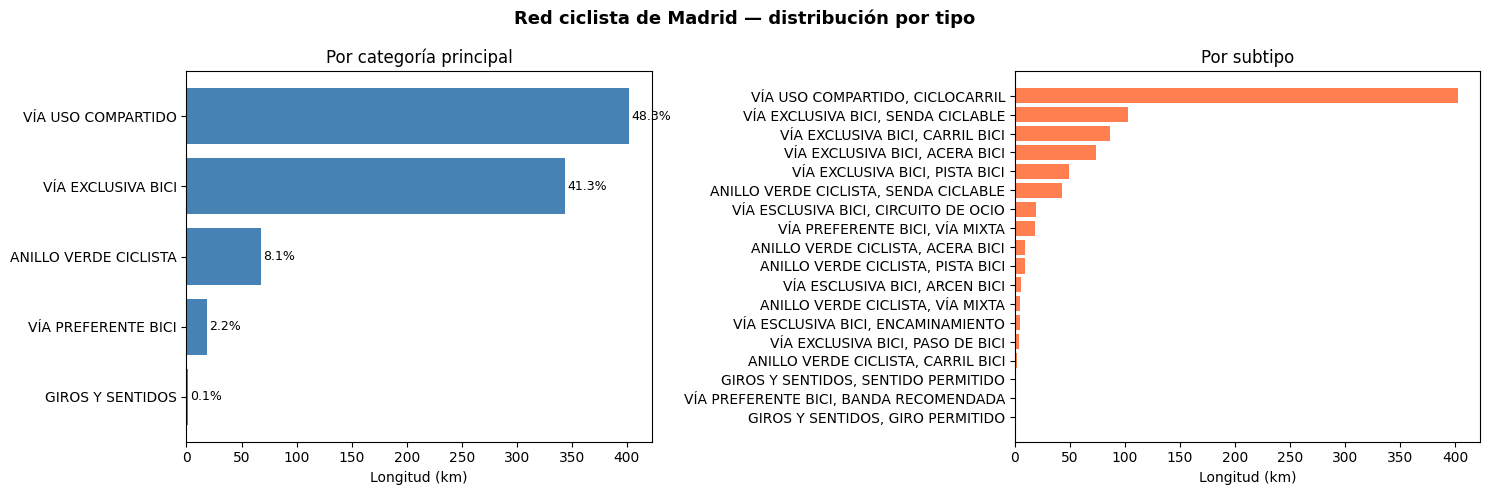

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Categorías principales
axes[0].barh(by_tipo["d_COD_TIPO"], by_tipo["km"], color="steelblue")
axes[0].set_xlabel("Longitud (km)")
axes[0].set_title("Por categoría principal")
axes[0].invert_yaxis()
for i, (km, pct) in enumerate(zip(by_tipo["km"], by_tipo["pct"])):
    axes[0].text(km + 2, i, f"{pct}%", va="center", fontsize=9)

# Subtipos
axes[1].barh(by_subtipo["d_COD_TI_1"], by_subtipo["km"], color="coral")
axes[1].set_xlabel("Longitud (km)")
axes[1].set_title("Por subtipo")
axes[1].invert_yaxis()

plt.suptitle("Red ciclista de Madrid — distribución por tipo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Mapa

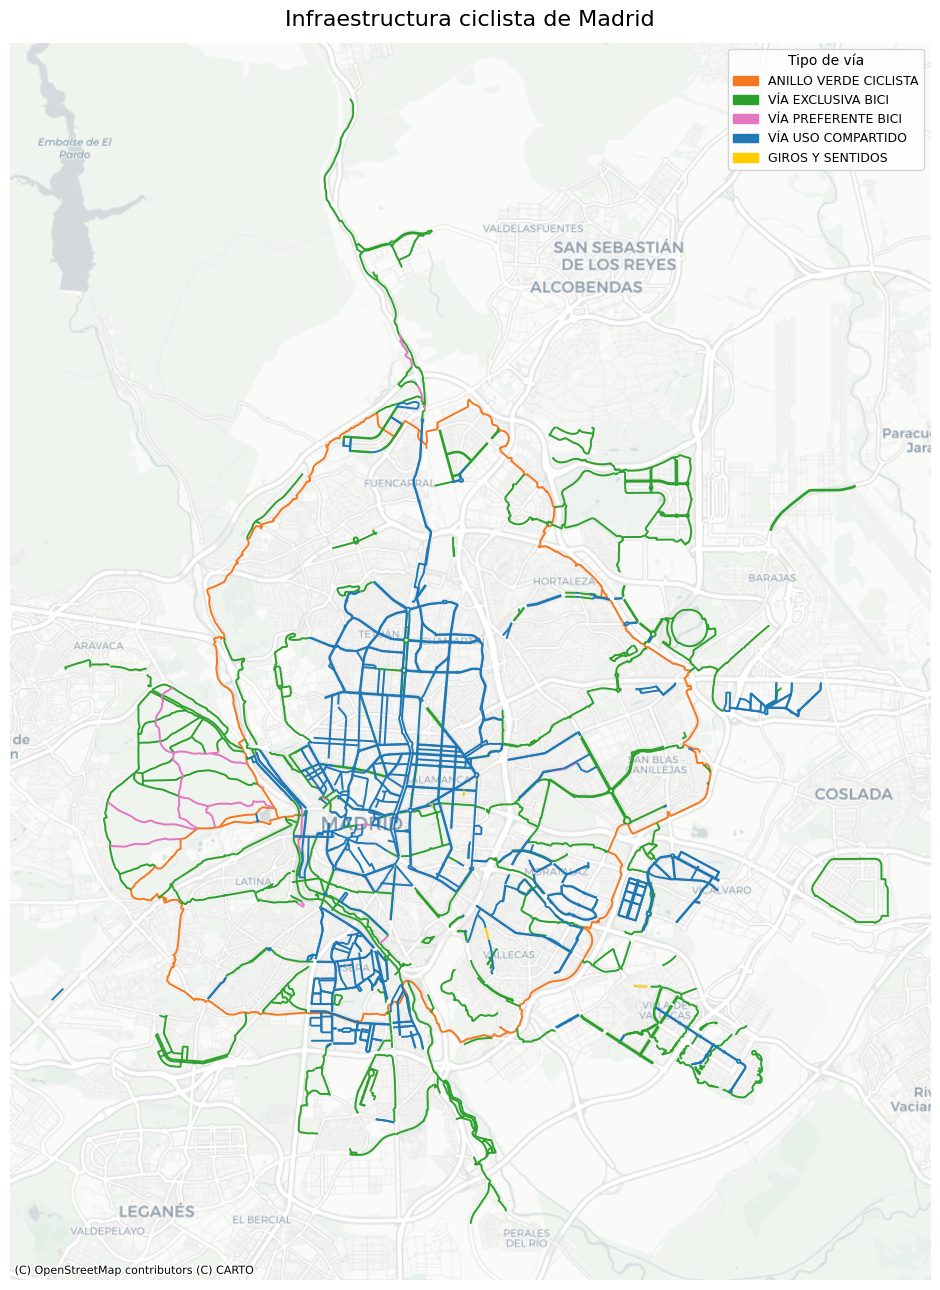

In [10]:
# Paleta de colores para las 5 categorías
PALETTE = {
    "ANILLO VERDE CICLISTA":  "#F47820",  # naranja
    "VÍA EXCLUSIVA BICI":    "#2CA02C",  # verde
    "VÍA PREFERENTE BICI":   "#E377C2",  # magenta
    "VÍA USO COMPARTIDO":    "#1F77B4",  # azul
    "GIROS Y SENTIDOS":       "#FFCC00",  # amarillo
}

# Reproyectar a Web Mercator para contextily
gdf_wm = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(13, 13))

for cat, color in PALETTE.items():
    subset = gdf_wm[gdf_wm["d_COD_TIPO"] == cat]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=1.4, label=cat)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

handles = [mpatches.Patch(color=c, label=l) for l, c in PALETTE.items()]
ax.legend(handles=handles, loc="upper right", fontsize=9, title="Tipo de vía")
ax.set_title("Infraestructura ciclista de Madrid", fontsize=16, pad=12)
ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Distribución de longitudes de tramo

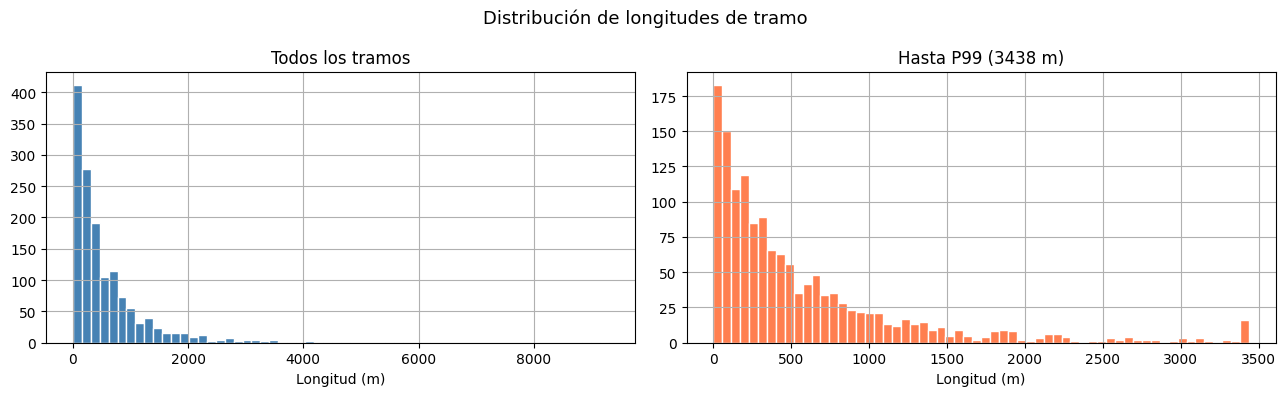

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gdf["length_m"].hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Longitud (m)")
axes[0].set_title("Todos los tramos")

p99 = gdf["length_m"].quantile(0.99)
gdf["length_m"].clip(upper=p99).hist(bins=60, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_xlabel("Longitud (m)")
axes[1].set_title(f"Hasta P99 ({p99:.0f} m)")

plt.suptitle("Distribución de longitudes de tramo", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Resumen

In [12]:
print("=" * 52)
print("  RESUMEN — Infraestructura Ciclista Madrid")
print("=" * 52)
print(f"  Total tramos:       {len(gdf):,}")
print(f"  Red total:          {gdf['length_m'].sum()/1000:.1f} km")
print(f"  Categorías:         {gdf['d_COD_TIPO'].nunique()}")
print(f"  Subtipos:           {gdf['d_COD_TI_1'].nunique()}")
print(f"  CRS:                {gdf.crs}")
print(f"  Geometría:          {gdf.geometry.geom_type.value_counts().to_dict()}")
print(f"  Bbox (ETRS89):      {gdf.total_bounds.round(0)}")
print("=" * 52)

  RESUMEN — Infraestructura Ciclista Madrid
  Total tramos:       1,437
  Red total:          833.9 km
  Categorías:         5
  Subtipos:           18
  CRS:                EPSG:25830
  Geometría:          {'LineString': 1288, 'MultiLineString': 149}
  Bbox (ETRS89):      [ 432355. 4464048.  453778. 4492719.]
